In [2]:
!pip install pandas

In [34]:
import numpy as np
import pandas as pd

np.random.seed(42)  # for reproducibility

n_samples = 100

true_w1 = 12
true_w2 = 6
true_w3 = 2
true_bias = 20

# generate random data for features 
employee_id = np.array([f"EMP_{i:03}" for i in range(1, n_samples+1)])
performance = np.random.randint(1, 11, n_samples)
years_of_exp = np.random.randint(1, 11, n_samples)
projects_completed = projects_completed = np.random.randint(1, 20, n_samples)
# calculate bonus
bonus = (true_w1 * performance) + (true_w2 * years_of_exp) + (true_w3 * projects_completed) + true_bias

# create dataframe
df = pd.DataFrame({
    'employee_id': employee_id,
    'performance': performance,
    'years_of_exp': years_of_exp,
    'projects_completed': projects_completed,
    'bonus': bonus
})

print(df.head())


  employee_id  performance  years_of_exp  projects_completed  bonus
0     EMP_001            7             2                  11    138
1     EMP_002            4             1                  16    106
2     EMP_003            8             7                  16    190
3     EMP_004            5             7                   1    124
4     EMP_005            7             8                   9    170


In [51]:
df.to_csv('data.csv', index=False)

In [35]:
import sys
!{sys.executable} -m pip install pandas


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Asus\torch_cuda\Scripts\python.exe -m pip install --upgrade pip


In [36]:
df.shape

(100, 5)

In [37]:
import torch

In [38]:
print(df['performance'])
type(df['performance'])

0      7
1      4
2      8
3      5
4      7
      ..
95    10
96     9
97     7
98     9
99     8
Name: performance, Length: 100, dtype: int32


pandas.Series

In [39]:
type(df['performance'].values)

numpy.ndarray

In [40]:
torch.tensor((df['performance'].values),dtype = torch.float32)

tensor([ 7.,  4.,  8.,  5.,  7., 10.,  3.,  7.,  8.,  5.,  4.,  8.,  8.,  3.,
         6.,  5.,  2.,  8.,  6.,  2.,  5.,  1., 10.,  6.,  9.,  1., 10.,  3.,
         7.,  4.,  9.,  3.,  5.,  3.,  7.,  5.,  9.,  7.,  2.,  4.,  9.,  2.,
        10.,  9., 10.,  5.,  2.,  4.,  7.,  8.,  3.,  1.,  4.,  2.,  8.,  4.,
         2.,  6.,  6., 10.,  4.,  6.,  2., 10.,  2., 10.,  4.,  8.,  7.,  9.,
         8.,  5.,  2.,  5.,  8., 10.,  9.,  9.,  1.,  9.,  7.,  9.,  8.,  1.,
         8.,  8.,  3.,  1.,  8.,  3.,  3.,  1.,  5., 10.,  7., 10.,  9.,  7.,
         9.,  8.])

In [41]:
# create tensors for all features
performance = torch.tensor((df['performance'].values),dtype = torch.float32)
years_of_exp =  torch.tensor((df['years_of_exp'].values),dtype = torch.float32)
projects_completed =  torch.tensor((df['projects_completed'].values),dtype = torch.float32)
bonus = torch.tensor((df['bonus'].values), dtype = torch.float32)

In [42]:
performance

tensor([ 7.,  4.,  8.,  5.,  7., 10.,  3.,  7.,  8.,  5.,  4.,  8.,  8.,  3.,
         6.,  5.,  2.,  8.,  6.,  2.,  5.,  1., 10.,  6.,  9.,  1., 10.,  3.,
         7.,  4.,  9.,  3.,  5.,  3.,  7.,  5.,  9.,  7.,  2.,  4.,  9.,  2.,
        10.,  9., 10.,  5.,  2.,  4.,  7.,  8.,  3.,  1.,  4.,  2.,  8.,  4.,
         2.,  6.,  6., 10.,  4.,  6.,  2., 10.,  2., 10.,  4.,  8.,  7.,  9.,
         8.,  5.,  2.,  5.,  8., 10.,  9.,  9.,  1.,  9.,  7.,  9.,  8.,  1.,
         8.,  8.,  3.,  1.,  8.,  3.,  3.,  1.,  5., 10.,  7., 10.,  9.,  7.,
         9.,  8.])

In [43]:
years_of_exp

tensor([ 2.,  1.,  7.,  7.,  8.,  5.,  3.,  8.,  6.,  3.,  1.,  3.,  5.,  3.,
         1.,  5., 10.,  7.,  7.,  9., 10., 10.,  3.,  7.,  1.,  4.,  4.,  5.,
         7.,  7.,  4.,  7.,  3.,  6.,  2., 10.,  9.,  5.,  6.,  4., 10.,  7.,
         9.,  7.,  1.,  1.,  9.,  9.,  4.,  9.,  3.,  7.,  6.,  8.,  9.,  5.,
         1.,  3., 10.,  8.,  6.,  8.,  9.,  4.,  1.,  1., 10.,  4.,  7.,  2.,
         3.,  1.,  5.,  1.,  8.,  1.,  1.,  2.,  2.,  6.,  7.,  5.,  1.,  1.,
         3.,  2.,  5., 10.,  6.,  7.,  4.,  7.,  8.,  1.,  6.,  8.,  5.,  4.,
         2.,  6.])

In [44]:
projects_completed

tensor([11., 16., 16.,  1.,  9.,  6., 16.,  3.,  4., 19.,  3., 19.,  7.,  9.,
         1.,  8.,  7., 18.,  8.,  1., 11., 18., 10.,  3.,  7., 16., 16., 17.,
         2.,  1., 16., 12.,  5.,  5.,  9.,  9.,  3., 19., 16., 16.,  3.,  1.,
        11., 17.,  8.,  4.,  6.,  8.,  3., 16.,  3., 18., 14., 18.,  2.,  3.,
        16.,  9.,  4.,  1.,  4.,  1., 14., 16.,  8.,  7.,  3., 17.,  1., 16.,
        12., 19., 14.,  6.,  6., 13., 19.,  8.,  2.,  1., 15.,  1.,  5., 16.,
        19.,  4.,  3., 17., 17., 12., 14.,  6.,  3.,  9.,  5., 17., 14.,  3.,
         1.,  1.])

In [45]:
#step 1 initialize wieghts with random initial values 
w1 = torch.rand(1,requires_grad = True)
w2 = torch.rand(1,requires_grad = True)
w3 = torch.rand(1,requires_grad = True)
bias= torch.rand(1,requires_grad = True)

In [46]:
epochs = 9300
learning_rate =0.001
loss_history = []

for epoch in range(epochs):
    
    pred_bonus = w1 * performance + w2 * years_of_exp + w3 * projects_completed + bias
    loss = ((pred_bonus - bonus)**2).mean()
    loss_history.append(loss.item())
    loss.backward()

    with torch.no_grad():
        w1 -= learning_rate * w1.grad
        w2 -= learning_rate * w2.grad
        w3 -= learning_rate * w3.grad
        bias -= learning_rate * bias.grad

    w1.grad.zero_()
    w2.grad.zero_()
    w3.grad.zero_()
    bias.grad.zero_()
    
    if epoch % 100 == 0:
        print(f"Epoch : {epoch}, Loss : {loss.item():0.2f}")

Epoch : 0, Loss : 17099.48
Epoch : 100, Loss : 26.73
Epoch : 200, Loss : 22.98
Epoch : 300, Loss : 22.28
Epoch : 400, Loss : 21.65
Epoch : 500, Loss : 21.04
Epoch : 600, Loss : 20.44
Epoch : 700, Loss : 19.86
Epoch : 800, Loss : 19.30
Epoch : 900, Loss : 18.75
Epoch : 1000, Loss : 18.22
Epoch : 1100, Loss : 17.71
Epoch : 1200, Loss : 17.21
Epoch : 1300, Loss : 16.72
Epoch : 1400, Loss : 16.25
Epoch : 1500, Loss : 15.79
Epoch : 1600, Loss : 15.34
Epoch : 1700, Loss : 14.91
Epoch : 1800, Loss : 14.49
Epoch : 1900, Loss : 14.08
Epoch : 2000, Loss : 13.68
Epoch : 2100, Loss : 13.29
Epoch : 2200, Loss : 12.91
Epoch : 2300, Loss : 12.55
Epoch : 2400, Loss : 12.19
Epoch : 2500, Loss : 11.85
Epoch : 2600, Loss : 11.51
Epoch : 2700, Loss : 11.19
Epoch : 2800, Loss : 10.87
Epoch : 2900, Loss : 10.56
Epoch : 3000, Loss : 10.27
Epoch : 3100, Loss : 9.97
Epoch : 3200, Loss : 9.69
Epoch : 3300, Loss : 9.42
Epoch : 3400, Loss : 9.15
Epoch : 3500, Loss : 8.89
Epoch : 3600, Loss : 8.64
Epoch : 3700, Lo

In [47]:
print("Learned Parameters:")
print("w1:", w1.item())
print("w2:", w2.item())
print("w3:", w3.item())
print("bias:", bias.item())

Learned Parameters:
w1: 12.316420555114746
w2: 6.300748825073242
w3: 2.112177848815918
bias: 15.177160263061523


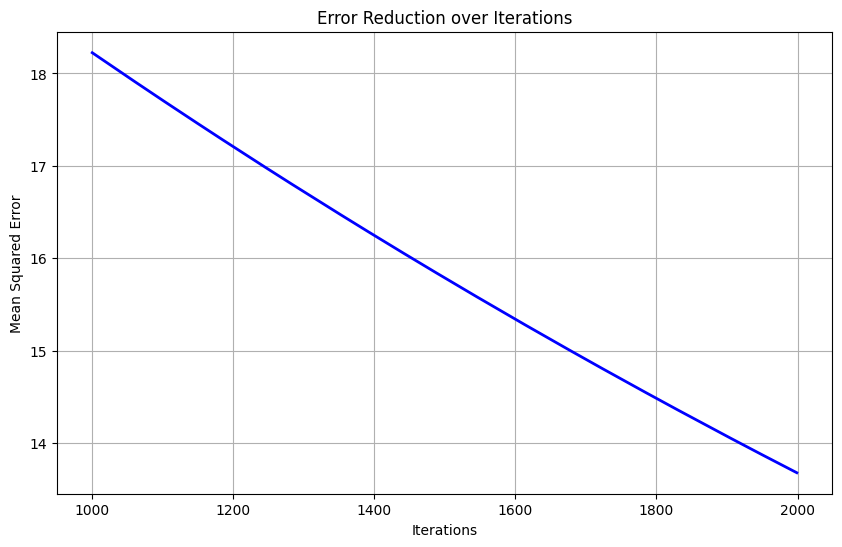